# Transform singular values with QSVT

**Download Notebook** - {nb-download}`qsvt.ipynb`

Build a block encoding of a complex matrix, choose a polynomial, and check the resulting quantum singular value transformation (QSVT) against a classical singular-value decomposition. The example uses [guppy](https://docs.quantinuum.com/guppy/language_guide/language_guide_index.html).

Run this notebook from a source checkout with the development dependencies installed. The repository default is little endian.

In [1]:
import numpy as np
from numpy.polynomial.polynomial import Polynomial
import zixy.qubit.pauli as zqp
from typing import no_type_check

from guppylang import guppy
from guppylang.std.builtins import comptime, array, dagger
from guppylang.std.quantum import qubit

from guppyalgos.algorithms.block_encoding.qsvt import QSVT
from guppyalgos.utils import ChebyshevPolynomial, QSPAngleFinder
from guppyalgos.testing import (
    get_unitary_projected,
    assert_allclose_ignorephase,
    Endianness
)
from guppyalgos.algorithms.block_encoding.lcu import (
    LCU,
    LCUData,
    build_double_cntrl_select,
)
from guppyalgos.algorithms.state_preparation import multiplexor_prep

## 1. Encode a complex matrix

Use the two-qubit operator

$$
A=0.5Z_0X_1+0.1iX_0Z_1+0.3iX_0X_1,\qquad \lambda=0.9.
$$

This matrix is not Hermitian. Its adjoint is obtained by conjugating the coefficients, since each Pauli string is Hermitian. QSVT needs block encodings of both $A/\lambda$ and $A^\dagger/\lambda$.

In [2]:
def ham_2q() -> zqp.ComplexTermSum:
    return zqp.ComplexTermSum.from_str("(0.5, Z0 X1), (0.1j, X0 Z1), (0.3j, X0 X1)")

def ham_2q_conj() -> zqp.ComplexTermSum:
    return zqp.ComplexTermSum.from_str("(0.5, Z0 X1), (-0.1j, X0 Z1), (-0.3j, X0 X1)")

ham_op = ham_2q()
ham_op_dagger = ham_2q_conj()

`LCUData` supplies the term weights and register sizes. Both encodings share PREPARE; conjugating the SELECT coefficients supplies the adjoint:

$$
B=P^\dagger SP,\qquad B^\dagger=P^\dagger S^\dagger P,
\qquad \langle00|B|00\rangle=A/\lambda.
$$

In [3]:
data = LCUData.from_hamiltonian(ham_op)
data_dagger = LCUData.from_hamiltonian(ham_op_dagger)
prepare = multiplexor_prep(data.amplitudes)

select = build_double_cntrl_select(data)
select_dagger = build_double_cntrl_select(data_dagger)

n_prep_qubits = data.n_prep_qubits
n_state_qubits = data.n_state_qubits

@guppy
@no_type_check
def unprepare(prep: array[qubit, n_prep_qubits]) -> None:
    with dagger:
        prepare(prep)

## 2. Choose the polynomial

Approximate the bounded, even function

$$
f(x)=\tfrac12\cos(5x),\qquad
p_{12}(x)=\sum_{k=0}^{12}c_kT_k(x),\qquad x\in[-1,1].
$$

`ChebyshevPolynomial` computes the approximation; `QSPAngleFinder` finds its phase sequence in the reflection convention used by `QSVT`. The phase values are in half-turns.

In [4]:
def target_fun(x):
    """Target function."""
    return np.cos(5 * x) / 2


# Since the function is even, we select an even degree
d_phi = 12
d_cheb = d_phi

target_fun_cheb = ChebyshevPolynomial(target_fun, d_cheb)
qsp_optimizer = QSPAngleFinder(
    d_phi=d_phi, target_polynomial=target_fun_cheb
)

phases = list(qsp_optimizer.phi)

## 3. Build a classical reference

Write $A/\lambda=U\Sigma V^\dagger$. For this even polynomial, QSVT acts on the right singular vectors:

$$
p^{(\mathrm{SV})}(A/\lambda)=V\,p(\Sigma)\,V^\dagger.
$$

For an odd polynomial the corresponding expression is $U\,p(\Sigma)\,V^\dagger$. The function below handles both cases. We compare against the fitted polynomial, separating circuit accuracy from approximation error.

In [5]:
from scipy.linalg import svd
from numpy.typing import NDArray

def scipy_qsvt(
    operator: NDArray[np.complex128], polynomial: Polynomial
) -> NDArray[np.complex128]:
    """Scipy implementation of QSVT.

    Polynomial transform of the singular values, where the SVD
    is performed using scipy.linalg.svd. For even polynomial,
    the right singular vectors are used, and for odd polynomial,
    the left singular vectors are used.

    Args:
    ----
        operator (npt.ndarray): matrix operator
        polynomial (Polynomial): polynomial to be applied to
        the singular values of the matrix

    """
    U, s, Vh = svd(operator, full_matrices=True)

    if (len(polynomial) - 1) % 2 == 0:
        # even polynomial
        # ∑_{k} Poly(s_k)|vk> <vk|
        # ONLY USES RIGHT SINGULAR VECS |vk>!
        qsvt = Vh.conj().T @ np.diag(polynomial(s)) @ Vh

    else:
        # odd polynomial
        # ∑_{k} Poly(s_k)|uk> <vk|
        qsvt = U @ np.diag(polynomial(s)) @ Vh

    return qsvt

In [6]:
poly_cos_np = np.polynomial.chebyshev.cheb2poly(qsp_optimizer.target_polynomial.coeffs)
poly_cos_np = Polynomial(poly_cos_np)

actual_hamiltonian = ham_op.to_sparse_matrix().toarray()
actual_hamiltonian_normalized = actual_hamiltonian / data.l1_norm
scipy_qsvt_matrix = scipy_qsvt(actual_hamiltonian_normalized, poly_cos_np)

## 4. Apply QSVT

Pass the two LCUs and the phase sequence to `QSVT`. The circuit borrows a preparation register, one signal qubit, and the system register. Initialize the preparation and signal qubits to zero.

In [7]:
@guppy
def qsvt_circ(
    prep_qreg: array[qubit, n_prep_qubits],
    signal_qreg: array[qubit, 1],
    select_qreg: array[qubit, n_state_qubits],
) -> None:
    QSVT(LCU(prepare, select, unprepare), 
         LCU(prepare, select_dagger, unprepare), 
         comptime(phases)).compose(signal_qreg[0], prep_qreg, select_qreg)

## 5. Check the encoded block

Project both auxiliary registers onto zero:

$$
M=(\langle00|_p\langle0|_s\otimes I)\,\mathcal U_{\mathrm{QSVT}}\,
(|00\rangle_p|0\rangle_s\otimes I)
\approx p^{(\mathrm{SV})}(A/\lambda).
$$

`get_unitary_projected` preserves the block's scale. The assertion allows an overall global phase and checks the full complex matrix.

In [8]:
post_selection = {
    "prep_qreg": [False for _ in range(n_prep_qubits)],
    "signal": [False],
}

guppy_h = get_unitary_projected(
    qsvt_circ, n_state_qubits, post_selection, endianness=Endianness.LITTLE
)

guppy_h

array([[-2.28558195e-02-2.50045187e-16j,  9.53240766e-16+1.38472763e-01j,
         1.11956617e-15-9.15747495e-17j,  4.51408010e-16+1.01841715e-15j],
       [-1.40232023e-15-1.38472763e-01j, -2.28558195e-02-7.11255119e-16j,
        -9.81654971e-17-1.40506612e-15j,  1.03182541e-15+1.75041488e-16j],
       [-8.90402979e-16-3.10134409e-17j,  2.55095953e-16-1.24459441e-15j,
        -2.28558195e-02-2.49920805e-16j,  1.30825595e-15+1.38472763e-01j],
       [ 1.76636366e-16+7.97034842e-16j, -9.78516939e-16-1.40584214e-16j,
        -1.49882807e-15-1.38472763e-01j, -2.28558195e-02-5.06450891e-16j]])

In [9]:
scipy_qsvt_matrix

array([[2.28556101e-02+0.j       , 0.00000000e+00-0.1384732j,
        0.00000000e+00+0.j       , 0.00000000e+00+0.j       ],
       [0.00000000e+00+0.1384732j, 2.28556101e-02+0.j       ,
        0.00000000e+00+0.j       , 0.00000000e+00+0.j       ],
       [0.00000000e+00+0.j       , 0.00000000e+00+0.j       ,
        2.28556101e-02+0.j       , 6.93889390e-18-0.1384732j],
       [0.00000000e+00+0.j       , 0.00000000e+00+0.j       ,
        0.00000000e+00+0.1384732j, 2.28556101e-02+0.j       ]])

In [10]:
assert_allclose_ignorephase(guppy_h, scipy_qsvt_matrix, threshold=1e-3)

### Compare matrix magnitudes

The shared color scale makes the classical and simulated blocks directly comparable. The numerical assertion above also checks their phases, which a magnitude plot cannot show.

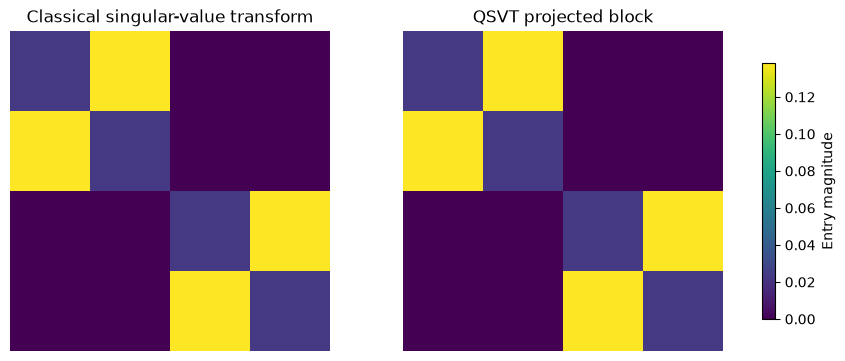

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")

vmax = max(np.abs(scipy_qsvt_matrix).max(), np.abs(guppy_h).max())
axes[0].imshow(np.abs(scipy_qsvt_matrix), cmap='viridis', vmin=0, vmax=vmax)
axes[0].set_title('Classical singular-value transform')
axes[0].axis('off')

plot = axes[1].imshow(np.abs(guppy_h), cmap='viridis', vmin=0, vmax=vmax)
axes[1].set_title('QSVT projected block')
axes[1].axis('off')

fig.colorbar(plot, ax=axes, label="Entry magnitude", shrink=0.8)
plt.show()